In [4]:
from google.colab import drive
drive.mount('/content/drive')



Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive


In [5]:
%tensorflow_version 2.x
import tensorflow as tf
# Ensure TensorFlow version 2.x
print(tf.__version__)

2.2.0-rc1


In [0]:
import h5py
import numpy as np

In [0]:
#Open the file as readonly
h5f = h5py.File("/content/drive/My Drive/GreatLakes/NeuralNetwork/Project2/SVHN_single_grey1.h5", 'r')
#Load the training, test and validaton set
X_train = h5f['X_train'][:]
y_train1 = h5f['y_train'][:]
X_test = h5f['X_test'][:]
y_test1 = h5f['y_test'][:]

h5f.close()


In [8]:
print(X_train.shape)

(42000, 32, 32)


In [9]:
print(X_test.shape)

(18000, 32, 32)


In [10]:
print(y_train1.shape)

(42000,)


In [11]:
print(y_test1.shape)

(18000,)


In [0]:
X_train = X_train.reshape(42000, 1024)
X_test = X_test.reshape(18000, 1024)

In [13]:
print(X_train.shape)
print(X_test.shape)

(42000, 1024)
(18000, 1024)


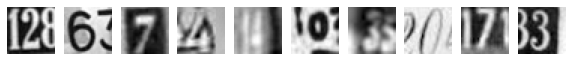

label for each of the above image: [2 6 7 4 4 0 3 0 7 3]


In [14]:
# visualizing the first 10 images in the dataset and their labels
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 1))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_train[i].reshape(32, 32), cmap="gray")
    plt.axis('off')
plt.show()
print('label for each of the above image: %s' % (y_train1[0:10]))

**DATA PREPROCESSING**

In [0]:
"""
X_train = X_train/255.0
X_test = X_test/255.0
"""
#Normlize the train and test data
X_train = tf.keras.utils.normalize(X_train, axis=1)
X_test = tf.keras.utils.normalize(X_test, axis=1)


In [16]:
#Find number of unique classes
numclasses = (np.unique(y_train1)).size
print(numclasses)

10


In [0]:
y_train1 = tf.keras.utils.to_categorical(y_train1, num_classes=numclasses)
y_test1 = tf.keras.utils.to_categorical(y_test1, num_classes=numclasses)

**BUILD MODEL FUNCTION**

In [0]:
def build_model(numHidden=2, drop=0.0, activationFn='relu', batchnormalize=False, optim='Adam'):
  ## input size
  input_dim = X_train.shape[1]

  input_nodes = input_dim
  output_nodes = 10
  hidden_nodes = 512 #(input+output)/2

  #Sequential Model
  model = tf.keras.models.Sequential()
  
  #Input Layer
  model.add(tf.keras.layers.Dense(input_nodes, input_shape=(X_train.shape[1],)))
  if batchnormalize:
    model.add(tf.keras.layers.BatchNormalization())
  model.add(tf.keras.layers.Activation(activationFn))
  #Dropout added at the time of regularization
  model.add(tf.keras.layers.Dropout(drop))
  
  for i in range(numHidden):
    model.add(tf.keras.layers.Dense(hidden_nodes))
    if batchnormalize:
      model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation(activationFn))
    #Dropout added at the time of regularization
    model.add(tf.keras.layers.Dropout(drop))

  #Output Layer
  model.add(tf.keras.layers.Dense(output_nodes, activation='softmax'))

  #Compile the model
  model.compile(optimizer=optim, loss='categorical_crossentropy', metrics=['accuracy'])
  return model


**PLOT MODEL FUNCTION**

In [0]:
def plot(history): # plot history
  from matplotlib import pyplot
  pyplot.plot(history.history['accuracy'], label='train')
  pyplot.plot(history.history['val_accuracy'], label='test')
  pyplot.legend()
  pyplot.show()

**EVALUATE MODEL FUNCTION**

In [0]:
def evaluate_model(model, Xtrain, ytrain, Xtest, ytest):
  print("EVALUATION OF TRAIN :\n")
  model.evaluate(Xtrain,  ytrain, verbose=2)
  print("\nEVALUATION OF TEST :\n")
  model.evaluate(Xtest,  ytest, verbose=2)

**BASE MODEL** 
We are trying with 2, 3 and 4 hidden layers and choose the one with better scores as Base Model 

Epoch 1/30
1313/1313 [==============================] - 31s 24ms/step - loss: 2.2567 - accuracy: 0.1203 - val_loss: 2.1274 - val_accuracy: 0.1661
Epoch 2/30
1313/1313 [==============================] - 31s 23ms/step - loss: 1.7935 - accuracy: 0.3262 - val_loss: 1.5477 - val_accuracy: 0.4458
Epoch 3/30
1313/1313 [==============================] - 31s 24ms/step - loss: 1.5295 - accuracy: 0.4556 - val_loss: 1.4681 - val_accuracy: 0.4863
Epoch 4/30
1313/1313 [==============================] - 31s 23ms/step - loss: 1.4458 - accuracy: 0.4958 - val_loss: 1.3949 - val_accuracy: 0.5210
Epoch 5/30
1313/1313 [==============================] - 31s 24ms/step - loss: 1.3952 - accuracy: 0.5207 - val_loss: 1.3808 - val_accuracy: 0.5346
Epoch 6/30
1313/1313 [==============================] - 31s 24ms/step - loss: 1.3406 - accuracy: 0.5420 - val_loss: 1.2824 - val_accuracy: 0.5709
Epoch 7/30
1313/1313 [==============================] - 31s 24ms/step - loss: 1.2999 - accuracy: 0.5592 - val_loss: 1.3172 -

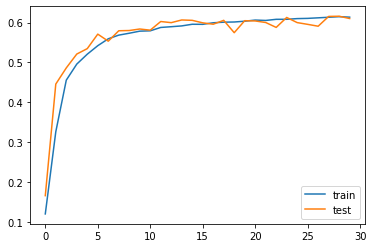

Epoch 1/30
1313/1313 [==============================] - 36s 28ms/step - loss: 2.3032 - accuracy: 0.0967 - val_loss: 2.3028 - val_accuracy: 0.0982
Epoch 2/30
1313/1313 [==============================] - 36s 27ms/step - loss: 2.3028 - accuracy: 0.0992 - val_loss: 2.3027 - val_accuracy: 0.0982
Epoch 3/30
1313/1313 [==============================] - 36s 27ms/step - loss: 2.3028 - accuracy: 0.0979 - val_loss: 2.3028 - val_accuracy: 0.1007
Epoch 4/30
1313/1313 [==============================] - 36s 28ms/step - loss: 2.3028 - accuracy: 0.1000 - val_loss: 2.3027 - val_accuracy: 0.1007
Epoch 5/30
1313/1313 [==============================] - 36s 27ms/step - loss: 2.3027 - accuracy: 0.0975 - val_loss: 2.3027 - val_accuracy: 0.0955
Epoch 6/30
1313/1313 [==============================] - 36s 27ms/step - loss: 2.3028 - accuracy: 0.0987 - val_loss: 2.3027 - val_accuracy: 0.0955
Epoch 7/30
1313/1313 [==============================] - 36s 28ms/step - loss: 2.3028 - accuracy: 0.0975 - val_loss: 2.3029 -

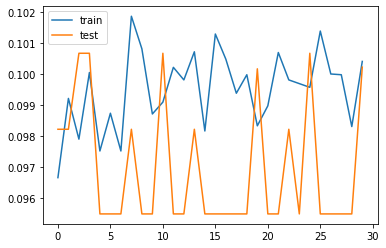

Epoch 1/30
1313/1313 [==============================] - 41s 31ms/step - loss: 2.3030 - accuracy: 0.0996 - val_loss: 2.3028 - val_accuracy: 0.0955
Epoch 2/30
1313/1313 [==============================] - 42s 32ms/step - loss: 2.3028 - accuracy: 0.0994 - val_loss: 2.3027 - val_accuracy: 0.0955
Epoch 3/30
1313/1313 [==============================] - 41s 31ms/step - loss: 2.3028 - accuracy: 0.0998 - val_loss: 2.3028 - val_accuracy: 0.0955
Epoch 4/30
1313/1313 [==============================] - 41s 31ms/step - loss: 2.3028 - accuracy: 0.1009 - val_loss: 2.3028 - val_accuracy: 0.0955
Epoch 5/30
1313/1313 [==============================] - 41s 32ms/step - loss: 2.3027 - accuracy: 0.1004 - val_loss: 2.3030 - val_accuracy: 0.0955
Epoch 6/30
1313/1313 [==============================] - 41s 31ms/step - loss: 2.3028 - accuracy: 0.1001 - val_loss: 2.3027 - val_accuracy: 0.0955
Epoch 7/30
1313/1313 [==============================] - 41s 31ms/step - loss: 2.3027 - accuracy: 0.1012 - val_loss: 2.3029 -

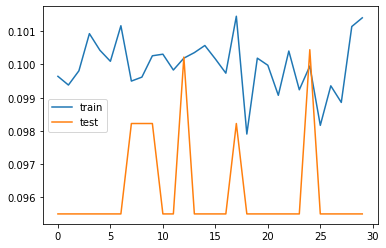

In [125]:
basemodel = build_model(numHidden=2)
# Train the model
history = basemodel.fit(X_train, y_train1, validation_data=(X_test, y_test1), epochs=30, batch_size=32)
print("BASE MODEL WITH 2 HIDDEN LAYERS")
plot(history)

basemodel = build_model(numHidden=3)
# Train the model
history = basemodel.fit(X_train, y_train1, validation_data=(X_test, y_test1), epochs=30, batch_size=32)
print("\n\nBASE MODEL WITH 3 HIDDEN LAYERS")
plot(history)

basemodel = build_model(numHidden=4)
# Train the model
history = basemodel.fit(X_train, y_train1, validation_data=(X_test, y_test1), epochs=30, batch_size=32)
print("\n\nBASE MODEL WITH 4 HIDDEN LAYERS")
plot(history)


Conclusion:Base Model

1. When run with 2,3 and 4 hidden layers. the best stable performance comparable beteen train and test was at 2 hidden layers. The performance was 0.6135 and 0.6101 for train and validation. Though the performance is not that good but Train and test graphs are comparable.

2. The base model configuration is numHidden=2, drop=0.0, activationFn='relu', batchnormalize=False, optim='Adam'

3. Epochs=30  Batch size = 32

**REGULARIZE MODEL USING BATCH NORMALIZATION**

Epoch 1/30
1313/1313 [==============================] - 33s 25ms/step - loss: 1.0291 - accuracy: 0.6683 - val_loss: 1.0288 - val_accuracy: 0.6854
Epoch 2/30
1313/1313 [==============================] - 32s 25ms/step - loss: 0.7079 - accuracy: 0.7775 - val_loss: 0.9510 - val_accuracy: 0.7141
Epoch 3/30
1313/1313 [==============================] - 33s 25ms/step - loss: 0.6067 - accuracy: 0.8067 - val_loss: 0.7454 - val_accuracy: 0.7702
Epoch 4/30
1313/1313 [==============================] - 33s 25ms/step - loss: 0.5456 - accuracy: 0.8271 - val_loss: 0.7083 - val_accuracy: 0.7927
Epoch 5/30
1313/1313 [==============================] - 33s 25ms/step - loss: 0.4935 - accuracy: 0.8413 - val_loss: 0.7697 - val_accuracy: 0.7724
Epoch 6/30
1313/1313 [==============================] - 33s 25ms/step - loss: 0.4475 - accuracy: 0.8580 - val_loss: 0.7948 - val_accuracy: 0.7792
Epoch 7/30
1313/1313 [==============================] - 33s 25ms/step - loss: 0.4086 - accuracy: 0.8692 - val_loss: 0.6350 -

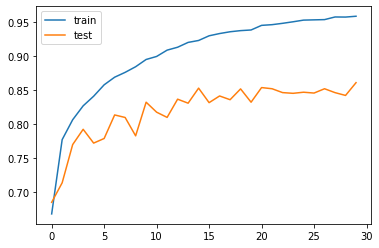

In [127]:
regmodel = build_model(numHidden=2, drop=0.0, activationFn='relu', batchnormalize=True, optim='Adam')
# Train the model
history = regmodel.fit(X_train, y_train1, validation_data=(X_test, y_test1), epochs=30, batch_size=32)
print("REG MODEL WITH 2 HIDDEN LAYERS")
plot(history)


**Conclusion Regularization : Batch Normalization**
 When base model was regularised using BatchNormalization, the accuracy of train has improved  upto 0.95, however the validation accuracy is 0.86. Though both the accuracies are good but the model seems to be overfit due to higher train score

Epochs=30 Batch size = 32

**REGULARIZE MODEL USING DROP OUT TO AVOID OVERFIT (Also Batch Normalization + Adam Optimizer)**

Epoch 1/30
1313/1313 [==============================] - 33s 25ms/step - loss: 1.2865 - accuracy: 0.5842 - val_loss: 0.9061 - val_accuracy: 0.7150
Epoch 2/30
1313/1313 [==============================] - 32s 24ms/step - loss: 0.9075 - accuracy: 0.7100 - val_loss: 0.8488 - val_accuracy: 0.7354
Epoch 3/30
1313/1313 [==============================] - 32s 25ms/step - loss: 0.8035 - accuracy: 0.7474 - val_loss: 0.7008 - val_accuracy: 0.7853
Epoch 4/30
1313/1313 [==============================] - 32s 25ms/step - loss: 0.7474 - accuracy: 0.7638 - val_loss: 0.6719 - val_accuracy: 0.7938
Epoch 5/30
1313/1313 [==============================] - 32s 24ms/step - loss: 0.6975 - accuracy: 0.7806 - val_loss: 0.6107 - val_accuracy: 0.8108
Epoch 6/30
1313/1313 [==============================] - 32s 24ms/step - loss: 0.6585 - accuracy: 0.7925 - val_loss: 0.6805 - val_accuracy: 0.7868
Epoch 7/30
1313/1313 [==============================] - 32s 24ms/step - loss: 0.6292 - accuracy: 0.8019 - val_loss: 0.5609 -

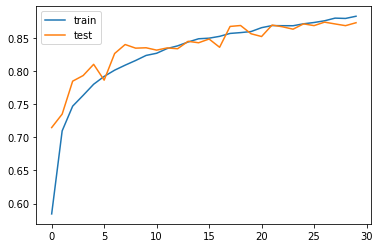

In [129]:
dropout_model = build_model(numHidden=2, drop=0.3, activationFn='relu', batchnormalize=True, optim='Adam')
# Train the model
history = dropout_model.fit(X_train, y_train1, validation_data=(X_test, y_test1), epochs=30, batch_size=32)
print("REG DROP OUT AND BATCHNORMALIZED MODEL WITH 2 HIDDEN LAYERS")
plot(history)


**Conclusion Regularization : Batch Normalization + Dropout**
 When base model was regularised using BatchNormalization as well as dropout of 0.3, the accuracy of train was 0.88, however the validation accuracy is 0.87. The model is genralized well as train and validation accuracies are comparable

Epochs=30 Batch size = 32, hidden layers =2 

**Trying RMSProp optimizer with batch normalization and drop out**

Epoch 1/30
1313/1313 [==============================] - 40s 30ms/step - loss: 1.2717 - accuracy: 0.5884 - val_loss: 1.1145 - val_accuracy: 0.6880
Epoch 2/30
1313/1313 [==============================] - 40s 31ms/step - loss: 0.9160 - accuracy: 0.7122 - val_loss: 1.0937 - val_accuracy: 0.7068
Epoch 3/30
1313/1313 [==============================] - 41s 31ms/step - loss: 0.8175 - accuracy: 0.7449 - val_loss: 0.9586 - val_accuracy: 0.7116
Epoch 4/30
1313/1313 [==============================] - 41s 31ms/step - loss: 0.7631 - accuracy: 0.7651 - val_loss: 0.9349 - val_accuracy: 0.7320
Epoch 5/30
1313/1313 [==============================] - 41s 31ms/step - loss: 0.7252 - accuracy: 0.7755 - val_loss: 0.7316 - val_accuracy: 0.7963
Epoch 6/30
1313/1313 [==============================] - 40s 30ms/step - loss: 0.7020 - accuracy: 0.7844 - val_loss: 0.6827 - val_accuracy: 0.8111
Epoch 7/30
1313/1313 [==============================] - 40s 30ms/step - loss: 0.6700 - accuracy: 0.7948 - val_loss: 0.8006 -

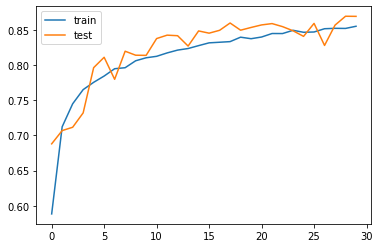

In [23]:
rmsprop_model = build_model(numHidden=2, drop=0.3, activationFn='relu', batchnormalize=True, optim='RMSProp')
# Train the model
history = rmsprop_model.fit(X_train, y_train1, validation_data=(X_test, y_test1), epochs=30, batch_size=32)
print("RMSPROP DROP OUT AND BATCHNORMALIZED MODEL WITH 2 HIDDEN LAYERS")
plot(history)

**Trying SGD optimizer with batch normalization and drop out**

Epoch 1/30
1313/1313 [==============================] - 28s 21ms/step - loss: 1.7426 - accuracy: 0.4081 - val_loss: 0.9835 - val_accuracy: 0.6969
Epoch 2/30
1313/1313 [==============================] - 28s 21ms/step - loss: 1.1824 - accuracy: 0.6143 - val_loss: 0.7869 - val_accuracy: 0.7583
Epoch 3/30
1313/1313 [==============================] - 27s 21ms/step - loss: 1.0206 - accuracy: 0.6718 - val_loss: 0.7086 - val_accuracy: 0.7824
Epoch 4/30
1313/1313 [==============================] - 27s 21ms/step - loss: 0.9141 - accuracy: 0.7073 - val_loss: 0.6557 - val_accuracy: 0.8027
Epoch 5/30
1313/1313 [==============================] - 27s 21ms/step - loss: 0.8614 - accuracy: 0.7239 - val_loss: 0.6319 - val_accuracy: 0.8062
Epoch 6/30
1313/1313 [==============================] - 28s 21ms/step - loss: 0.8050 - accuracy: 0.7445 - val_loss: 0.5791 - val_accuracy: 0.8270
Epoch 7/30
1313/1313 [==============================] - 27s 20ms/step - loss: 0.7649 - accuracy: 0.7545 - val_loss: 0.5868 -

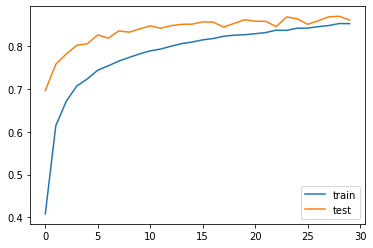

In [24]:
sgd_model = build_model(numHidden=2, drop=0.3, activationFn='relu', batchnormalize=True, optim='SGD')
# Train the model
history = sgd_model.fit(X_train, y_train1, validation_data=(X_test, y_test1), epochs=30, batch_size=32)
print("SGD MODEL DROP OUT AND BATCHNORMALIZED MODEL WITH 2 HIDDEN LAYERS")
plot(history)

**Conclusion Optimizers**
1. With Adam as Optimizer, accuracy is Train 0.88 and Test 0.87. Train and test accuracy graph is showing sharp upward trend after 30 epochs indicating more scope of improvement after increasing epochs
2. With RMSProp as optimizer, the accuracy is less than Adam. TRain - 0.8551, Validation - 0.87. Though the train and test accuracy graph is showing upward trend after 30 epochs but it is less steep than Adam
3. With SGD as optimizer, the accuracy is less than Adam. TRain - 0.8551, Validation - 0.86. The train and test accuracy graph seems to flatten after 30 epochs.

Adam is chosen as final optimizer

**OPTIMIZE ADAM OPTIMIZER WITH DIFFERENT LEARNING RATES (We had checked with 0.001 default value) AND INITIALIZATION VALUES**

Epoch 1/30
1313/1313 [==============================] - 41s 31ms/step - loss: 1.1712 - accuracy: 0.6203 - val_loss: 0.8961 - val_accuracy: 0.7157
Epoch 2/30
1313/1313 [==============================] - 42s 32ms/step - loss: 0.8263 - accuracy: 0.7386 - val_loss: 0.7783 - val_accuracy: 0.7540
Epoch 3/30
1313/1313 [==============================] - 41s 32ms/step - loss: 0.7214 - accuracy: 0.7714 - val_loss: 0.6968 - val_accuracy: 0.7818
Epoch 4/30
1313/1313 [==============================] - 41s 31ms/step - loss: 0.6693 - accuracy: 0.7896 - val_loss: 0.6210 - val_accuracy: 0.8111
Epoch 5/30
1313/1313 [==============================] - 42s 32ms/step - loss: 0.6236 - accuracy: 0.8029 - val_loss: 0.6272 - val_accuracy: 0.8031
Epoch 6/30
1313/1313 [==============================] - 41s 31ms/step - loss: 0.5883 - accuracy: 0.8121 - val_loss: 0.6228 - val_accuracy: 0.8083
Epoch 7/30
1313/1313 [==============================] - 40s 30ms/step - loss: 0.5544 - accuracy: 0.8225 - val_loss: 0.6564 -

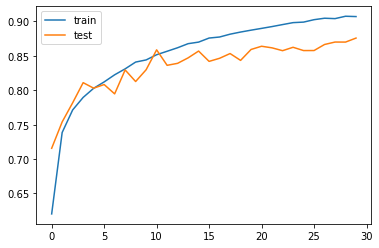

In [31]:
adam_opt = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
adamopt_model = build_model(numHidden=2, drop=0.2, activationFn='relu', batchnormalize=True, optim=adam_opt)
# Train the model
history = adamopt_model.fit(X_train, y_train1, validation_data=(X_test, y_test1), epochs=30, batch_size=32)
print("ADAM OPTIMIZER LEARNING RATE 0.001 DROP OUT 0.2 AND BATCHNORMALIZED MODEL WITH 2 HIDDEN LAYERS")
plot(history)

Adam was tried with diffrent learning rate(0.001,0.01, 0.1,1), drop out 0.2 (rest of the parameters were taken same as obtained through previous steps ) and the learning rate of 0.001 led to faster convergence and better accuracy
Train 0.90 and Validation 0.88

**Final Model With all parameters till last step and 50 epochs**

Epoch 1/50
1313/1313 [==============================] - 35s 26ms/step - loss: 1.1704 - accuracy: 0.6229 - val_loss: 0.8949 - val_accuracy: 0.7200
Epoch 2/50
1313/1313 [==============================] - 35s 26ms/step - loss: 0.8236 - accuracy: 0.7383 - val_loss: 0.7748 - val_accuracy: 0.7628
Epoch 3/50
1313/1313 [==============================] - 34s 26ms/step - loss: 0.7346 - accuracy: 0.7668 - val_loss: 0.7088 - val_accuracy: 0.7818
Epoch 4/50
1313/1313 [==============================] - 35s 26ms/step - loss: 0.6649 - accuracy: 0.7893 - val_loss: 0.6452 - val_accuracy: 0.7987
Epoch 5/50
1313/1313 [==============================] - 34s 26ms/step - loss: 0.6211 - accuracy: 0.8027 - val_loss: 0.7675 - val_accuracy: 0.7601
Epoch 6/50
1313/1313 [==============================] - 34s 26ms/step - loss: 0.5873 - accuracy: 0.8129 - val_loss: 0.5878 - val_accuracy: 0.8221
Epoch 7/50
1313/1313 [==============================] - 35s 26ms/step - loss: 0.5557 - accuracy: 0.8238 - val_loss: 0.5611 -

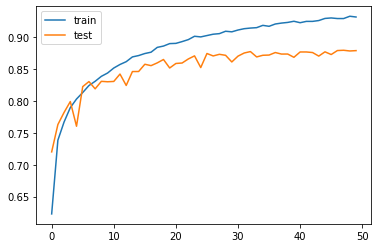

In [40]:
  EPOCHS = 50
  PATIENCE = 5

  ## input size
  input_dim = X_train.shape[1]
  input_nodes = input_dim
  output_nodes = 10
  hidden_nodes = 512 #(input+output)/2
  activationFn = 'relu'

  #Sequential Model
  final_model = tf.keras.models.Sequential()
  
  #Input Layer
  final_model.add(tf.keras.layers.Dense(input_nodes, input_shape=(X_train.shape[1],)))
  final_model.add(tf.keras.layers.BatchNormalization())
  final_model.add(tf.keras.layers.Activation(activationFn))
  final_model.add(tf.keras.layers.Dropout(0.2))
  
  #Hidden layer 1
  final_model.add(tf.keras.layers.Dense(hidden_nodes))
  final_model.add(tf.keras.layers.BatchNormalization())
  final_model.add(tf.keras.layers.Activation(activationFn))
  final_model.add(tf.keras.layers.Dropout(0.2))

  #Hidden Layer 2
  final_model.add(tf.keras.layers.Dense(hidden_nodes))
  final_model.add(tf.keras.layers.BatchNormalization())
  final_model.add(tf.keras.layers.Activation(activationFn))
  final_model.add(tf.keras.layers.Dropout(0.2))

  #Output Layer
  final_model.add(tf.keras.layers.Dense(output_nodes, activation='softmax'))

  #Compile the model with final optimized adam as decided in previous step
  adam = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
  final_model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

  history = final_model.fit(X_train, y_train1, validation_data=(X_test, y_test1), epochs=50, batch_size=32)
  print("FINAL MODEL")
  plot(history)



**CROSS VALIDATION WITH FINAL MODEL TO GET MEAN AND STANDARD DEVIATION**

In [0]:
"""
#fit our model to the traing data using KerasClassifier
from sklearn.model_selection import cross_val_score

#classifier = tf.keras.wrappers.scikit_learn.KerasClassifier(build_fn = build_model, batch_size = 10, epochs = 100 )
accuracies = cross_val_score(estimator = final_model, X = X_train, y = y_train1, cv = 3, n_jobs = -1)
mean = accuracies.mean()
std = accuracies.std()
"""

**FUNCTION FOR ACCURACY OF MODEL**

In [0]:
def model_accuracy(model, Xtrain, ytrain, Xtest, ytest):
  from  sklearn.metrics import accuracy_score, confusion_matrix, classification_report
  
  print("EVALUATION OF TRAIN :\n")
  loss_and_metrics1 = model.evaluate(Xtrain, ytrain)
  print(loss_and_metrics1)
  
  print("\nEVALUATION OF TEST :\n")
  loss_and_metrics = model.evaluate(Xtest, ytest)
  print(loss_and_metrics)

  y_pred = model.predict_classes(X_test)
  #model.predict_proba(X_test)[:, 1]

  #Print the Accuracy score and confusion matrix
  #print("\nACCURACY SCORE IS :\n",accuracy_score(ytest, y_pred))
  
  print("\nCONFUSION MATRIX FOR ACTUAL vs PREDICTED IS :\n",confusion_matrix(np.argmax(ytest, axis = 1), y_pred))
  
   #Print complete classification report
  print("\nCLASSIFICATION REPORT IS :\n")
  print(classification_report(np.argmax(ytest, axis = 1), y_pred))

**SUMMARIZE THE FINAL MODEL**

In [43]:
final_model.summary()

Model: "sequential_13"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_49 (Dense)             (None, 1024)              1049600   
_________________________________________________________________
batch_normalization_36 (Batc (None, 1024)              4096      
_________________________________________________________________
activation_36 (Activation)   (None, 1024)              0         
_________________________________________________________________
dropout_36 (Dropout)         (None, 1024)              0         
_________________________________________________________________
dense_50 (Dense)             (None, 512)               524800    
_________________________________________________________________
batch_normalization_37 (Batc (None, 512)               2048      
_________________________________________________________________
activation_37 (Activation)   (None, 512)             

In [55]:
#Get accuracy of model
model_accuracy(final_model, X_train, y_train1, X_test, y_test1)
#Note: 30 epochs gave better generalization as seen in penultimate final model. 
#However, with 50 epochs accuracy was improved of train but genrlaization reduced alittle.

EVALUATION OF TRAIN :

1313/1313 [==============================] - 9s 7ms/step - loss: 0.0562 - accuracy: 0.9877
[0.056232936680316925, 0.9877380728721619]

EVALUATION OF TEST :

563/563 [==============================] - 4s 7ms/step - loss: 0.5099 - accuracy: 0.8784
[0.5098650455474854, 0.8784444332122803]

CONFUSION MATRIX FOR ACTUAL vs PREDICTED IS :
 [[1664   33    2   19   21    2   16   21   17   19]
 [  20 1654    9   26   45    8    9   32   16    9]
 [  18   26 1569   48   33   10    5   52   19   23]
 [  10   31   13 1476   27   80   17   25   24   16]
 [  13   48    8   22 1663    8   14   10    5   21]
 [  14   13   12   98    9 1510   55    7   26   24]
 [  42   20    6   19   37   39 1595   12   53    9]
 [  11   58   19   20   16    8    8 1653    9    6]
 [  31   38   10   54   20   18   75    9 1515   42]
 [  50   36   11   53   37   34   20   21   29 1513]]

CLASSIFICATION REPORT IS :

              precision    recall  f1-score   support

           0       0.89    

**CONCLUSIONS**


Following sequence was followed to arrive at final model

1.The **base model** configuration is numHidden=2, drop=0.0, activationFn='relu', batchnormalize=False, optim='Adam', Run with Epochs=30  Batch size = 32. The performance was 0.6135 and 0.6101 for train and validation
*Note: Base model was created by trying 2, 3 and 4 hidden layers. With increase in number of hidden layers the accuracies were reducing. Best performance was with 2 hidden layers, number of neurons = 512 in hidden layers*

2.**Regularization/HyperParameter Tuning :** 

**a. Batch Normalization**
 When base model was regularised using BatchNormalization, the accuracy of train has improved  upto 0.95, however the validation accuracy is 0.86. Though both the accuracies are good but the model seems to be overfit due to higher train score

 **b. Drop Out**
 Drop out was done to avoid overfitting. Updated base model with dropout of 0.3 and BatchNormalization, the accuracy of train was 0.88 and that of validation accuracy was 0.87. The model is genralized well as train and validation accuracies are comparable

3.**Optimizers :** 
Adam, SGD and RMSProp were tried with different learning rates and best optimizer came out to be Adam with best learning rate of 0.001. Adams accuracy curve was steeper than rest of two and didnot flatten out till 30 epochs so this was taken as final optimizer and its best learning rate was found to be 0.001. It led to faster convergence and better accuracy Train 0.90 and Validation 0.88

**4.Batch Normalization tried After Activation**
Train accuracy 0.85 and Validation accuracy 0.87

**5 Final Model**

The final modelling was done keeping generalization and good accuracy score in mind

The final report is

Train loss: 0.0562 - accuracy: 0.9877
Test loss: 0.5099 - accuracy: 0.8784


In [0]:
"""
**CONFUSION MATRIX FOR ACTUAL vs PREDICTED IS**

 [[1664   33    2   19   21    2   16   21   17   19]
 [  20 1654    9   26   45    8    9   32   16    9]
 [  18   26 1569   48   33   10    5   52   19   23]
 [  10   31   13 1476   27   80   17   25   24   16]
 [  13   48    8   22 1663    8   14   10    5   21]
 [  14   13   12   98    9 1510   55    7   26   24]
 [  42   20    6   19   37   39 1595   12   53    9]
 [  11   58   19   20   16    8    8 1653    9    6]
 [  31   38   10   54   20   18   75    9 1515   42]
 [  50   36   11   53   37   34   20   21   29 1513]]

Diagonals indicate the actual matching with predicted count for each digit

Off diagonals indicate the incorrect match of actual and predicted for each digit

For example for 0 33 is the number of 0s predicted as 1

CLASSIFICATION REPORT
Indicates precision and recall of maximum digits is above 0.84

"""
